<div >
<img src = "../banner.jpg" />
</div>

<a target="_blank" href="https://colab.research.google.com/github/ignaciomsarmiento/BDML_202610/blob/main/Lecture09/Notebook_arboles.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


# CARTs

## Predicting House Prices

Our objective today is to construct a model to predict house prices. From Rosen's landmark paper "Hedonic Prices and Implicit Markets: Product Differentiation in Pure Competition" (1974), we know that a vector of its characteristics describes a differentiated good.

In the case of a house, these characteristics may include structural attributes (e.g., number of bedrooms), neighborhood public services (e.g., local school quality), and local amenities (e.g., crime, air quality, etc). Thus, we can write the market price of the house as:

$$
Price=f(structural\,attributes,amenities,...)
$$


However, Rosen's theory doesn't tell us much about the functional form of $f$. 

## CARTS: Example

Let's load the packages:

In [1]:
# install.packages("pacman") #run this line if you use Google Colab

In [2]:
#packages
require("pacman")
p_load("tidyverse","ggplot2")

Loading required package: pacman



 And the toy data set:

In [3]:
db<-read.csv('https://raw.githubusercontent.com/ignaciomsarmiento/datasets/main/toy_houses.csv')

In [4]:
head(db)

,price,habitaciones,DCBD
,<dbl>,<int>,<dbl>
1,162753.09,3,1.190307
2,73131.30,0,1.910839
3,162757.45,2,1.227716
4,73127.75,1,1.824990
5,73128.71,0,1.915576
6,98715.60,3,1.505208


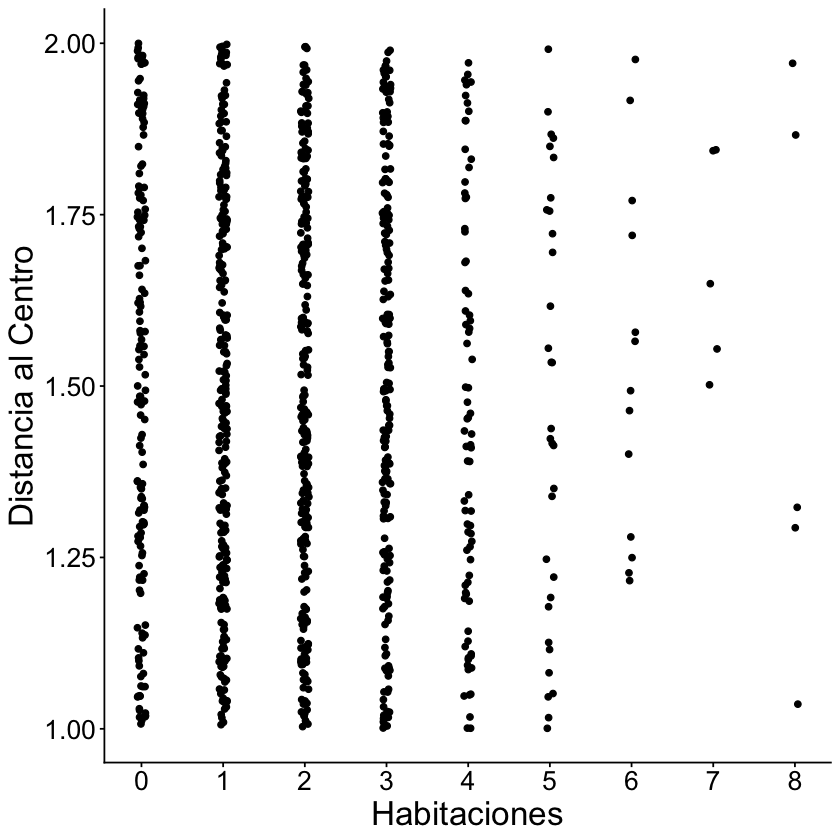

In [5]:
ggplot(db) +
  geom_point(aes(x=habitaciones,y=DCBD),position=position_jitter(width = .05)) +
  scale_x_continuous(breaks=seq(0,8,1)) +
  theme_classic() +
  xlab("Habitaciones") +
  ylab("Distancia al Centro") +
  theme(legend.position =  "none",
      text=element_text(size=20))

### Algorithm


-  Datos: $y_{n\times 1}$  y $X_{n\times k}$ 

-  Definiciones

      -  *j* es la variable que parte el espacio 
      - *s* es el punto de partición


-  Definimos los siguientes semiplanos

\begin{align}
R_1(j,s)=\{X|X_j\leq s\} \,\,\, \& \,\,\, R_2(j,s)=\{X|X_j > s\}
\end{align}

-  *El problema*: buscar la variable de partición $X_j$ y el punto $s$ de forma tal que 


\begin{align}
\underset{j,s}{min} \left[ \underset{y_{R_1}}{min}\sum_{x_i\in R_1(j,s)}(y-\gamma_{R_1})^2+ \underset{y_{R_2}}{min}\sum_{x_i\in R_2(j,s)}(y-\gamma_{R_2})^2\right]
\end{align}



#### Algorithm in R

Sin embargo, no construimos el árbol a mano, usamos el paquete `rpart`, que implementa el algoritmo de árboles de decisión para regresión y clasificación. Este paquete permite ajustar modelos de manera rápida y sencilla:

In [6]:
p_load("rpart")

In [7]:
mytree<-rpart(price~DCBD+habitaciones,data=db)

In [8]:
mytree

n= 1000 

node), split, n, deviance, yval
      * denotes terminal node

1) root 1000 1.716337e+12 123534.30  
  2) DCBD>=1.499274 483 6.982083e+10  81553.15  
    4) habitaciones< 2.5 324 3.060291e+03  73130.58 *
    5) habitaciones>=2.5 159 1.696944e+03  98716.14 *
  3) DCBD< 1.499274 517 4.730729e+03 162754.70 *

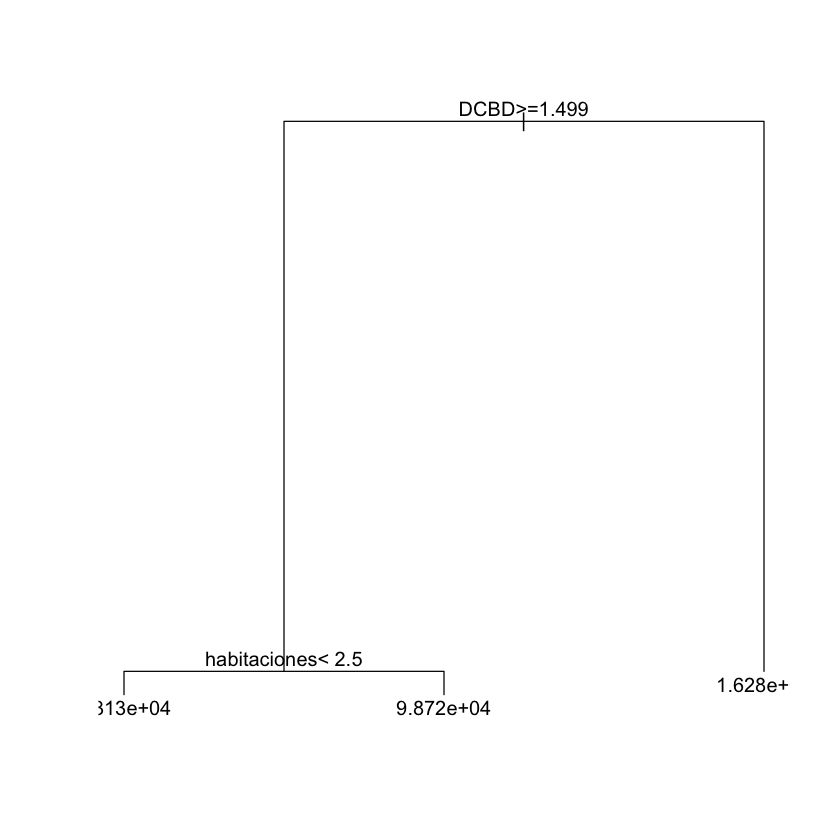

In [9]:
plot(mytree)
text(mytree)

Para visualizar árboles de decisión de forma mas "bonita", podemos usar el paquete `rpart.plot`, que extiende las capacidades de rpart con funciones gráficas más potentes y estéticas. La función principal es `prp()` qye permite crear gráficos detallados del árbol entrenado. En el siguiente ejemplo, usamos varias opciones para mejorar la presentación del árbol:

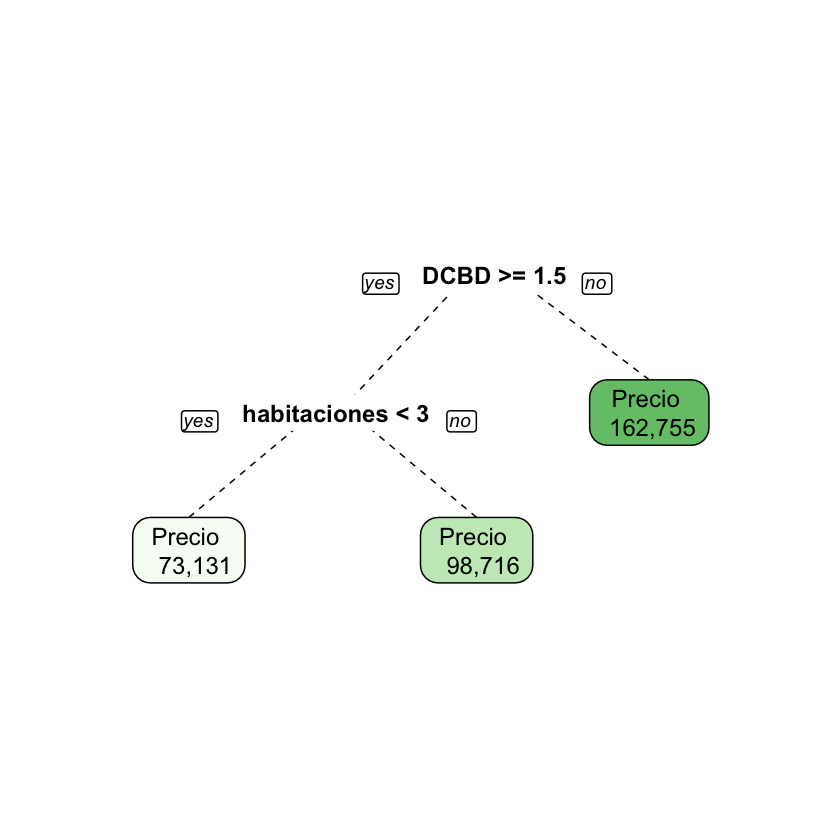

In [10]:
p_load("rpart.plot")

prp(mytree, under = TRUE, branch.lty = 2, yesno = 2, faclen = 0, varlen=15,tweak=1.2,clip.facs= TRUE,box.palette = "Greens",compress=TRUE,ycompress = TRUE,node.fun=function(x, labs, digits, varlen) paste("Precio \n", format(round(mytree$frame$yval, 0), nsmall=0, big.mark=",")))

Recordemos que la forma general del arbol es
$$
f(x_{i};\{R_{j},\gamma_{j}\}_{1}^{J})=\sum_{j=1}^{J}\gamma_{j}I(x\in R_{j})
$$

Entonces en este caso, el precio predicho por el  árbol es 

\begin{align}
\hat{Precio} = 162,754.67 I(DCBD<1.5) + 98,716.14 I(DCBD>=1.5 \& habitaciones>=3) + 73,130.58 I(DCBD>=1.5 \& habitaciones<3) 
\end{align}


# Clasificación

Para trabajar los pasos de clasificación basada en probabilidad, utilizaremos un conjunto de datos reales sobre desempleo de la Encuesta Permanente de Hogares (EPH) de Argentina. Este conjunto de datos incluye variables socioeconómicas y demográficas que nos permitirán predecir si una persona está desempleada o no.  

La predicción del desempleo es un problema clásico de clasificación y sigue siendo una de las áreas clave de aplicación en el aprendizaje automático: usamos información previa sobre la condición laboral de las personas (empleado versus desempleado) para entrenar un modelo que pueda predecir el estado de empleo en nuevos casos.  

\begin{align}
Desempleado_i = f(X_i) + u_i
\end{align}

donde $Desempleado_i$ es una variable dicotómica que toma el valor de 1 si el individuo \( i \) está desempleado y 0 en caso contrario.

In [11]:
# Leer los datos desde un archivo RDS alojado en GitHub
db <- readRDS(url("https://github.com/ignaciomsarmiento/datasets/blob/main/desempelo_arg_2010.Rds?raw=true"))

Antes de comenzar con el análisis, es fundamental realizar algunas tareas de limpieza y preparación de los datos, comúnmente conocidas como housekeeping. Estas tareas incluyen la filtración de datos para quedarnos con los relevantes, la conversión de variables categóricas a factores sin niveles innecesarios y la recodificación de valores para facilitar la interpretación. A continuación, se detallan los pasos realizados:

In [12]:

# Filtrar los datos para incluir solo observaciones de "Partidos del GBA", "Ciudad de Buenos Aires" y "Gran La Plata"
# Para que sea un poquito más rapido el analisis
db <- db %>% filter(ciudad %in% c("Partidos del GBA", "Ciudad de Buenos Aires", "Gran La Plata"))

# Filtrar niveles vacíos, el siguiente código no funciona porque solo elimina las filas con "Ns./Nr.",  
# pero el nivel sigue existiendo en la estructura del factor.  
# Esto sucede porque R no elimina automáticamente los niveles de un factor al filtrar filas.  
# Un nivel es una categoría posible dentro de una variable de tipo factor, incluso si no tiene observaciones.  
# db <- db %>% filter(nivel_ed != "Ns./Nr.")

# Eliminar niveles vacíos del factor nivel_ed que quedaron después del filtrado
db$nivel_ed <- droplevels(db$nivel_ed)


# Eliminar niveles innecesarios de la variable tipo_vivienda
db$tipo_vivienda <- droplevels(db$tipo_vivienda)

# Eliminar niveles innecesarios de la variable parentesco
db$parentesco <- droplevels(db$parentesco)

# Recodificar la variable tipo_vivienda agrupando ciertas categorías en "Otros"
db <- db %>% mutate(tipo_vivienda = recode(tipo_vivienda,
                                           "Pieza de inquilino" = "Otros",
                                           "Pieza en hotel/pension" = "Otros",
                                           "Local no construido para habitacion" = "Otros"))

# Convertir la variable mujer en un factor con etiquetas más descriptivas (0 = "hombre", 1 = "mujer")
db <- db %>% mutate(mujer = factor(mujer, levels = c(0,1), labels = c("hombre", "mujer")))


## Prediciendo el Desempleo en Gran La Plata

Ahora entrenaremos un modelo para predecir el desempleo en Gran La Plata. Para ello, utilizaremos los datos de "Partidos del GBA" y "Ciudad de Buenos Aires" como conjunto de entrenamiento y evaluaremos su desempeño en Gran La Plata, que será nuestra muestra fuera de muestra.

Este enfoque tiene sentido porque Gran La Plata comparte características socioeconómicas y demográficas con estas regiones, lo que sugiere que un modelo entrenado en "Partidos del GBA" y "Ciudad de Buenos Aires" podría generalizar razonablemente bien. Para respaldar esta decisión, exploraremos las estadísticas descriptivas de los predictores clave en las tres regiones.

<div >
<img src = "../Lecture08/figs/Aglomerado_Gran_Buenos_Aires.png" />
</div>

In [13]:
# Crear variable indicadora para Gran La Plata (1) vs. Resto (0) como factor con etiquetas descriptivas
db <- db %>%
  mutate(gran_la_plata = factor(ifelse(ciudad == "Gran La Plata", 1, 0),
                                levels = c(0,1), 
                                labels = c("Resto", "Gran La Plata")))

# Seleccionar variables de interés
variables_interes <- c("gran_la_plata", "edad", "mujer", "nivel_ed", 
                        "parentesco", "estado_civil", "tipo_vivienda", 
                        "ing_tot_fam", "total_miembros_hogar", "miembros_hogar_menores10")



In [14]:
# Definir conjunto de entrenamiento (Partidos del GBA y Ciudad de Buenos Aires)
train <- db %>% filter(ciudad %in% c("Partidos del GBA", "Ciudad de Buenos Aires"))

# Definir conjunto de test/prueba/validación (Gran La Plata)
test  <- db %>% filter(ciudad == "Gran La Plata")

- **`train`** se usa para entrenar el modelo con los datos de *Partidos del GBA* y *Ciudad de Buenos Aires*.
- **`test`** se usa para evaluar la función estimada en *Gran La Plata* y medir su desempeño.

In [15]:
# Me guardo la variable numérica, por las dudas
train <- train %>% mutate(desempleado_num = desempleado)
test  <- test  %>% mutate(desempleado_num = desempleado)

# Clave que "desempleado" sea el primer nivel
train <- train %>% mutate(desempleado = factor(desempleado, levels = c(1,0), labels = c("desempleado","empleado")))
test  <- test  %>% mutate(desempleado = factor(desempleado, levels = c(1,0), labels = c("desempleado","empleado")))


In [16]:
p_load("rpart")
desempleado_tree<-rpart(desempleado~edad+mujer+nivel_ed+ parentesco +
                        estado_civil+tipo_vivienda+ing_tot_fam+total_miembros_hogar+miembros_hogar_menores10,  control = rpart.control(cp = 0.003), data=train, method="class")





In [17]:
desempleado_tree

n= 12054 

node), split, n, loss, yval, (yprob)
      * denotes terminal node

  1) root 12054 1020 empleado (0.08461921 0.91538079)  
    2) edad< 25.5 2332  454 empleado (0.19468268 0.80531732)  
      4) ing_tot_fam< 2210 386  139 empleado (0.36010363 0.63989637)  
        8) parentesco=Hijo/a - Hijastro/a,Nieto/a,Hermano/a 239  117 empleado (0.48953975 0.51046025)  
         16) edad>=16.5 231  114 desempleado (0.50649351 0.49350649)  
           32) edad< 20.5 105   42 desempleado (0.60000000 0.40000000)  
             64) nivel_ed=Secundaria Incompleta,Secundaria Completa 72   24 desempleado (0.66666667 0.33333333) *
             65) nivel_ed=Primaria Incompleta (incluye educación especial),Primaria Completa,Superior Universitaria Incompleta 33   15 empleado (0.45454545 0.54545455)  
              130) ing_tot_fam>=1870 12    4 desempleado (0.66666667 0.33333333) *
              131) ing_tot_fam< 1870 21    7 empleado (0.33333333 0.66666667) *
           33) edad>=20.5 126   54 e

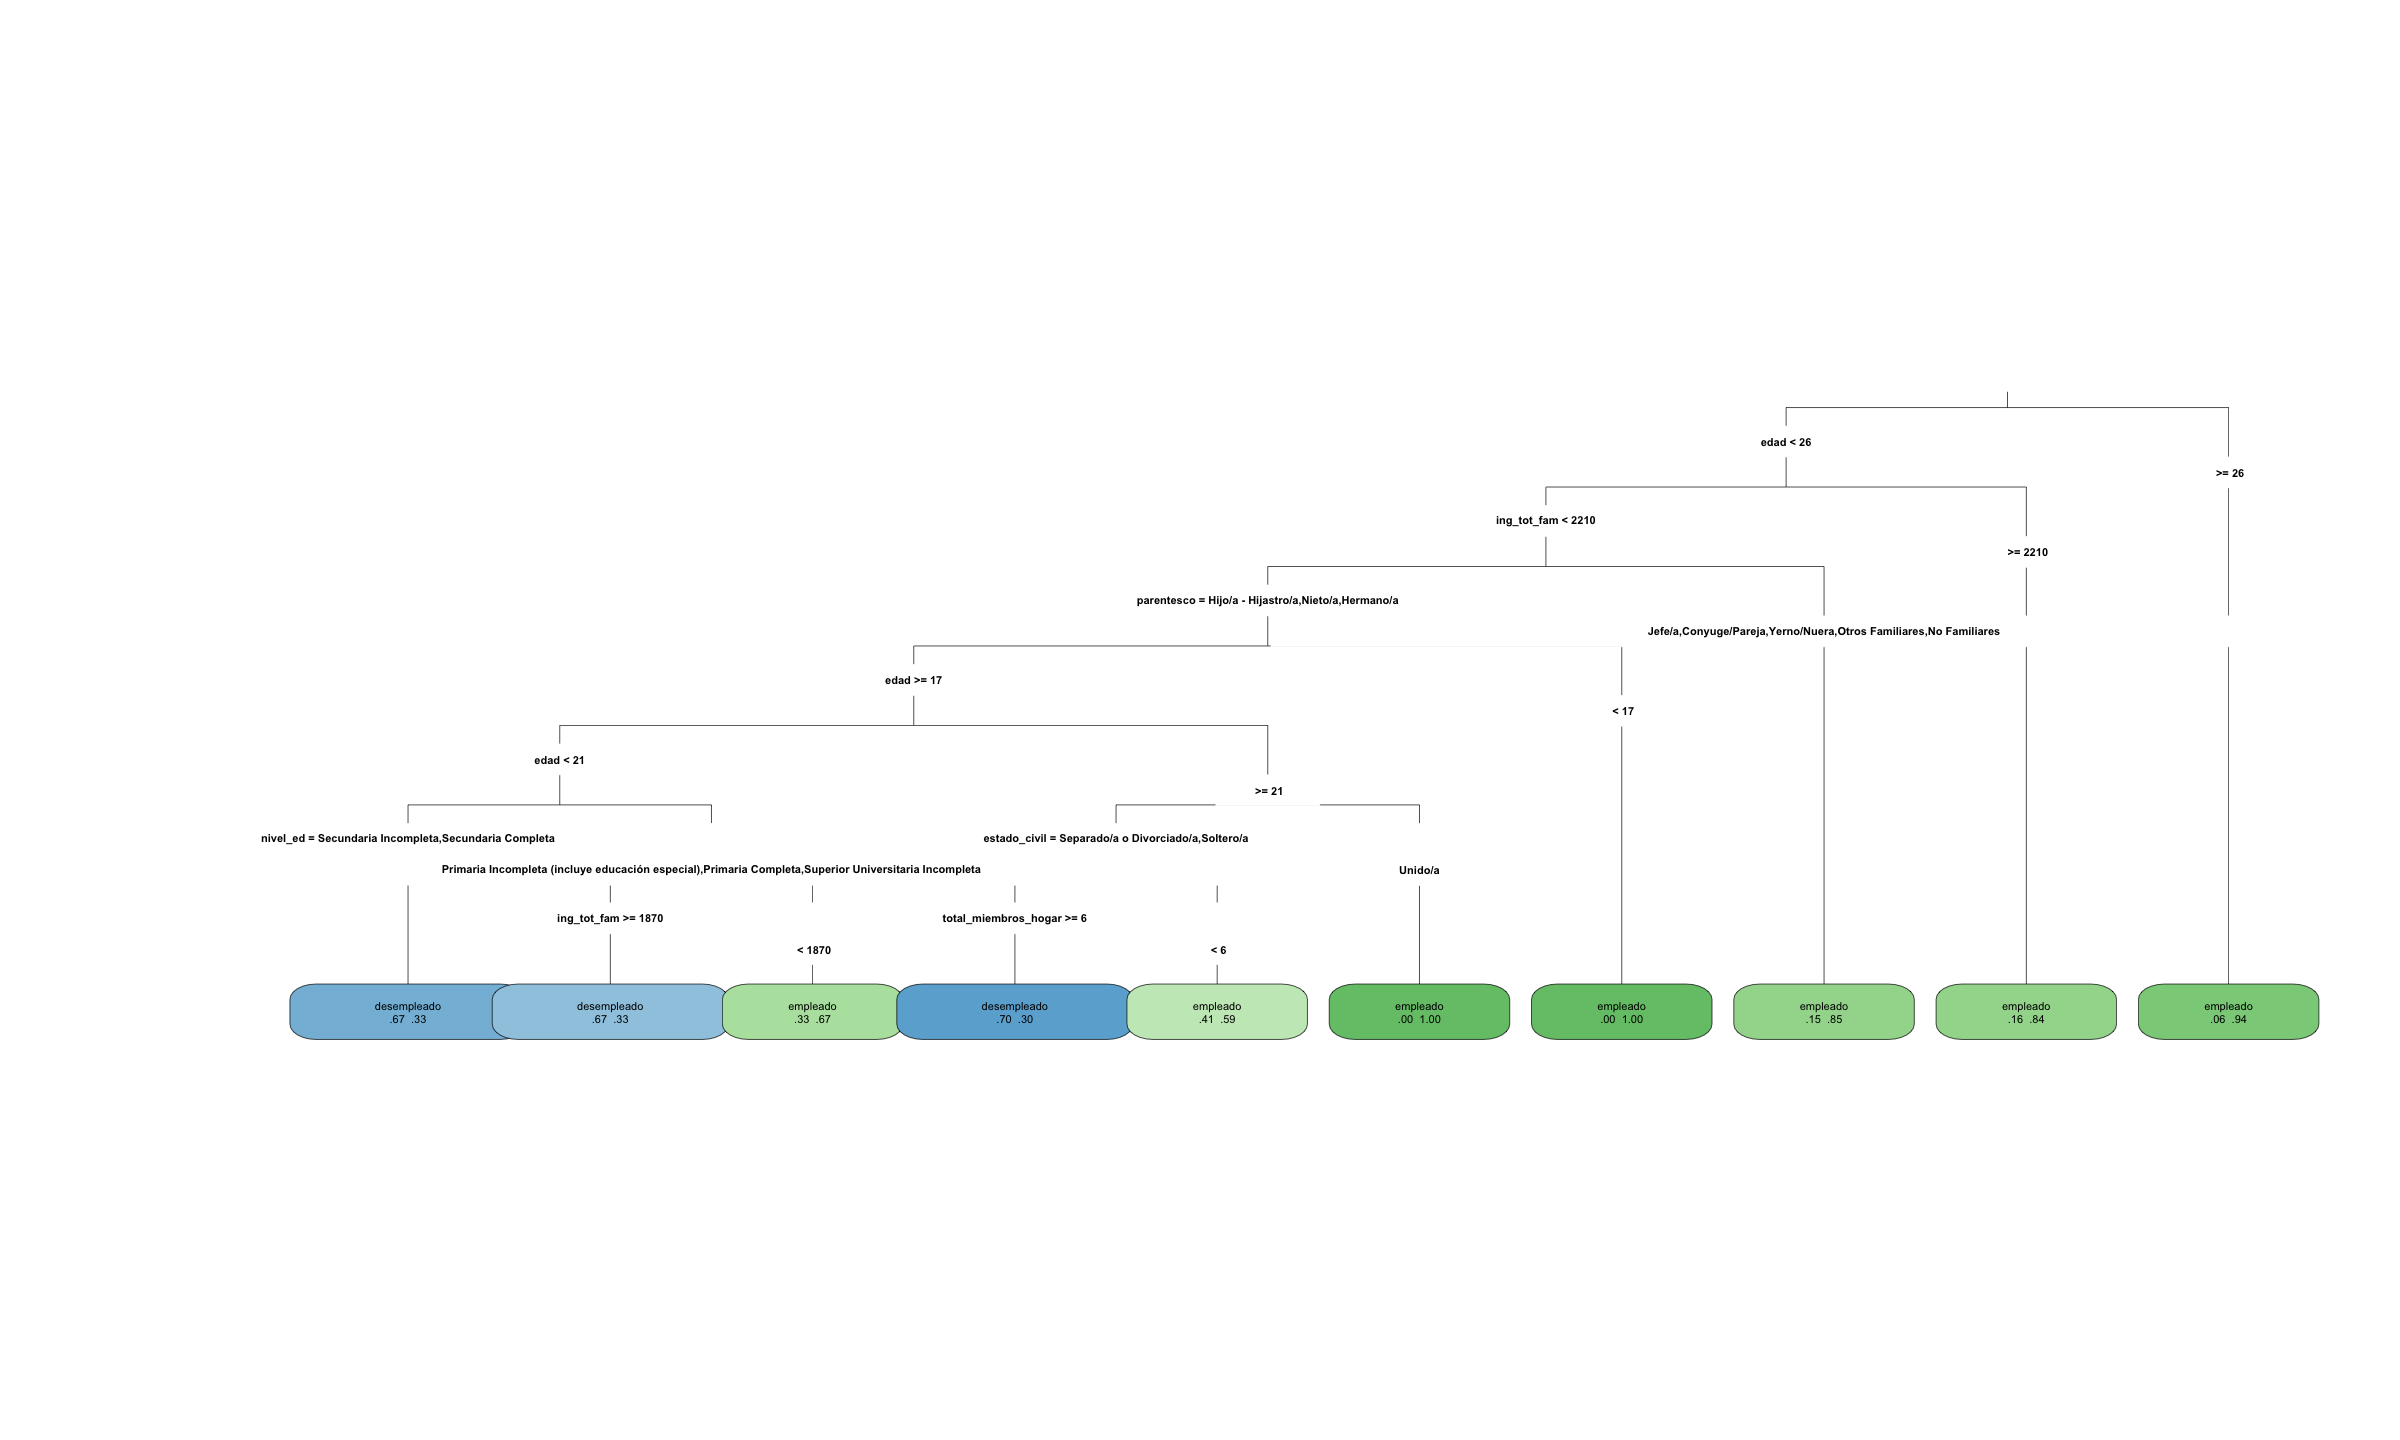

In [24]:
options(repr.plot.width = 20, repr.plot.height = 12)
rpart.plot(desempleado_tree,
           extra=4,
           type=3,
           tweak=1.3)

### Sobreajuste

<div >
<img src = "figures/tree_uba.png" width="300"/>
</div>


- Cost complexity pruning (implementado en Caret con `method=rpart`)

- Fijar la profundidad del árbol. (implementado en Caret `method=rpart2` (pero tiene varios bugs))

- Fijar la mínima cantidad de datos que están contenidos dentro de cada hoja. 

- `tidymodels` implementa todos

##### Implementación con Caret

In [16]:
p_load("caret", "ROSE", "smotefamily")


In [18]:
tree_formula <- desempleado ~ edad + mujer + nivel_ed + parentesco +
  estado_civil + tipo_vivienda + ing_tot_fam + total_miembros_hogar + miembros_hogar_menores10

# Armamos una matriz de diseño numérica para que luego SMOTE y ROSE
# corran sin problemas y la comparación sea homogénea.
x_train_tree <- as.data.frame(model.matrix(tree_formula, data = train)[, -1])
x_test_tree  <- as.data.frame(model.matrix(tree_formula, data = test)[, -1])

colnames(x_train_tree) <- make.names(colnames(x_train_tree))
colnames(x_test_tree)  <- colnames(x_train_tree)

tree_train_matrix <- x_train_tree %>% mutate(desempleado = train$desempleado)

dim(tree_train_matrix)


[1] 12054    27

In [19]:
head(tree_train_matrix)


,edad,mujermujer,nivel_edPrimaria.Completa,nivel_edSecundaria.Incompleta,nivel_edSecundaria.Completa,nivel_edSuperior.Universitaria.Incompleta,nivel_edSuperior.Universitaria.Completa,nivel_edSin.instrucción,parentescoConyuge.Pareja,parentescoHijo.a...Hijastro.a,⋯,estado_civilCasado.a,estado_civilSeparado.a.o.Divorciado.a,estado_civilViudo.a,estado_civilSoltero.a,tipo_viviendaDepartamento,tipo_viviendaOtros,ing_tot_fam,total_miembros_hogar,miembros_hogar_menores10,desempleado
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,31,0,0,0,0,1,0,0,0,0,⋯,0,0,0,0,0,0,8400,3,1,empleado
2,33,1,0,0,0,0,1,0,1,0,⋯,0,0,0,0,0,0,8400,3,1,empleado
3,48,0,1,0,0,0,0,0,0,0,⋯,1,0,0,0,0,0,3150,3,0,empleado
4,46,1,0,1,0,0,0,0,1,0,⋯,1,0,0,0,0,0,3150,3,0,empleado
5,63,0,0,0,0,1,0,0,0,0,⋯,1,0,0,0,0,0,3550,2,0,empleado
6,50,0,0,0,0,0,1,0,0,0,⋯,1,0,0,0,0,0,3500,3,0,empleado


In [54]:
ctrl_tree <- trainControl(
  method = "cv",
  number = 5,
  summaryFunction = twoClassSummary,
  classProbs = TRUE,
  verboseIter = FALSE,
  savePredictions = TRUE
)

cp_grid <- expand.grid(cp = seq(0, 0.02, length.out = 20))


In [59]:
set.seed(1410)
tree_model_base <- train(
  desempleado ~ .,
  method = "rpart",
  data = tree_train_matrix,
  tuneGrid = cp_grid,
  trControl = ctrl_tree,
  metric = "Sens"
)

tree_model_base


CART 

12054 samples
   26 predictor
    2 classes: 'desempleado', 'empleado' 

No pre-processing
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 9643, 9643, 9643, 9643, 9644 
Resampling results across tuning parameters:

  cp           ROC        Sens        Spec     
  0.000000000  0.7250568  0.10882353  0.9734457
  0.001052632  0.6976266  0.08725490  0.9873124
  0.002105263  0.6392848  0.05882353  0.9936559
  0.003157895  0.5810922  0.03235294  0.9964653
  0.004210526  0.5239863  0.01274510  0.9989126
  0.005263158  0.5000000  0.00000000  1.0000000
  0.006315789  0.5000000  0.00000000  1.0000000
  0.007368421  0.5000000  0.00000000  1.0000000
  0.008421053  0.5000000  0.00000000  1.0000000
  0.009473684  0.5000000  0.00000000  1.0000000
  0.010526316  0.5000000  0.00000000  1.0000000
  0.011578947  0.5000000  0.00000000  1.0000000
  0.012631579  0.5000000  0.00000000  1.0000000
  0.013684211  0.5000000  0.00000000  1.0000000
  0.014736842  0.5000000  0.00000000  1.000

In [60]:
tree_model_base$bestTune

tree_model_base$results %>%
  select(cp, ROC, Sens, Spec)


,cp
,<dbl>
1,0


,cp,ROC,Sens,Spec
,<dbl>,<dbl>,<dbl>,<dbl>
1,0.000000000,0.7250568,0.10882353,0.9734457
2,0.001052632,0.6976266,0.08725490,0.9873124
3,0.002105263,0.6392848,0.05882353,0.9936559
4,0.003157895,0.5810922,0.03235294,0.9964653
5,0.004210526,0.5239863,0.01274510,0.9989126
6,0.005263158,0.5000000,0.00000000,1.0000000
7,0.006315789,0.5000000,0.00000000,1.0000000
8,0.007368421,0.5000000,0.00000000,1.0000000
9,0.008421053,0.5000000,0.00000000,1.0000000


In [61]:
# Evaluando en el Test Set
test <- test %>% mutate(desempleo_hat_tree_base = predict(tree_model_base, newdata = x_test_tree, type = "raw"))


In [62]:
# Matriz de Confusión
cm_tree_base <- confusionMatrix(
  data = test$desempleo_hat_tree_base,
  reference = test$desempleado,
  positive = "desempleado",
  mode = "prec_recall"
)

cm_tree_base


Confusion Matrix and Statistics

             Reference
Prediction    desempleado empleado
  desempleado          17       36
  empleado            120     1790
                                          
               Accuracy : 0.9205          
                 95% CI : (0.9077, 0.9321)
    No Information Rate : 0.9302          
    P-Value [Acc > NIR] : 0.9558          
                                          
                  Kappa : 0.1457          
                                          
 Mcnemar's Test P-Value : 3.026e-11       
                                          
              Precision : 0.32075         
                 Recall : 0.12409         
                     F1 : 0.17895         
             Prevalence : 0.06979         
         Detection Rate : 0.00866         
   Detection Prevalence : 0.02700         
      Balanced Accuracy : 0.55219         
                                          
       'Positive' Class : desempleado     
                      

In [63]:
# guardo en un data frame
df_tree_base <- data.frame(
  Model = "Sin remuestreo",
  CP_Optimo = tree_model_base$bestTune$cp,
  Accuracy = cm_tree_base$overall["Accuracy"],
  Precision = cm_tree_base$byClass["Precision"],
  Recall = cm_tree_base$byClass["Recall"],
  F1_Score = cm_tree_base$byClass["F1"]
)
rownames(df_tree_base) <- NULL

metrics_df <- df_tree_base

metrics_df


Model,CP_Optimo,Accuracy,Precision,Recall,F1_Score
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Sin remuestreo,0,0.9205298,0.3207547,0.1240876,0.1789474


### Remuestreo

A partir de acá repetimos el mismo esquema de `Lecture08`, pero reemplazando el logit por un árbol de clasificación con **cost-complexity pruning**. En todos los casos usamos `rpart` y dejamos que `caret` elija el mejor `cp` en validación cruzada.


<div >
<img src = "../Lecture08/figs/sampling_methods.png" />
</div>


### Submuestreo (*Down Sampling*)


In [64]:
set.seed(1103)
downSampledTreeTrain <- downSample(
  x = x_train_tree,
  y = train$desempleado,
  yname = "desempleado"
)

dim(tree_train_matrix)


[1] 12054    27

In [65]:
dim(downSampledTreeTrain)


[1] 2040   27

In [66]:
table(downSampledTreeTrain$desempleado)



desempleado    empleado 
       1020        1020 

In [67]:
set.seed(1410)
tree_model_downsample <- train(
  desempleado ~ .,
  method = "rpart",
  data = downSampledTreeTrain,
  tuneGrid = cp_grid,
  trControl = ctrl_tree,
  metric = "Sens"
)

tree_model_downsample


CART 

2040 samples
  26 predictor
   2 classes: 'desempleado', 'empleado' 

No pre-processing
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 1632, 1632, 1632, 1632, 1632 
Resampling results across tuning parameters:

  cp           ROC        Sens       Spec     
  0.000000000  0.7320213  0.6549020  0.6529412
  0.001052632  0.7338500  0.6676471  0.6568627
  0.002105263  0.7297025  0.6794118  0.6823529
  0.003157895  0.7269488  0.6941176  0.6852941
  0.004210526  0.7220012  0.7186275  0.6617647
  0.005263158  0.7292652  0.7333333  0.6549020
  0.006315789  0.7232411  0.7294118  0.6617647
  0.007368421  0.7210448  0.7196078  0.6676471
  0.008421053  0.7206243  0.7225490  0.6647059
  0.009473684  0.7206243  0.7225490  0.6647059
  0.010526316  0.7206243  0.7225490  0.6647059
  0.011578947  0.7200644  0.7068627  0.6715686
  0.012631579  0.7200644  0.7068627  0.6715686
  0.013684211  0.7200644  0.7068627  0.6715686
  0.014736842  0.7200644  0.7068627  0.6715686
  0.015789474 

In [68]:
# Evaluando en el Test Set
test <- test %>% mutate(desempleo_hat_tree_downsample = predict(tree_model_downsample, newdata = x_test_tree, type = "raw"))


In [69]:
# Matriz de Confusión
cm_tree_downsample <- confusionMatrix(
  data = test$desempleo_hat_tree_downsample,
  reference = test$desempleado,
  positive = "desempleado",
  mode = "prec_recall"
)

cm_tree_downsample


Confusion Matrix and Statistics

             Reference
Prediction    desempleado empleado
  desempleado         102      607
  empleado             35     1219
                                          
               Accuracy : 0.6729          
                 95% CI : (0.6517, 0.6937)
    No Information Rate : 0.9302          
    P-Value [Acc > NIR] : 1               
                                          
                  Kappa : 0.1406          
                                          
 Mcnemar's Test P-Value : <2e-16          
                                          
              Precision : 0.14386         
                 Recall : 0.74453         
                     F1 : 0.24113         
             Prevalence : 0.06979         
         Detection Rate : 0.05196         
   Detection Prevalence : 0.36118         
      Balanced Accuracy : 0.70605         
                                          
       'Positive' Class : desempleado     
                      

In [70]:
# guardo en un data frame
df_tree_downsample <- data.frame(
  Model = "Downsample",
  CP_Optimo = tree_model_downsample$bestTune$cp,
  Accuracy = cm_tree_downsample$overall["Accuracy"],
  Precision = cm_tree_downsample$byClass["Precision"],
  Recall = cm_tree_downsample$byClass["Recall"],
  F1_Score = cm_tree_downsample$byClass["F1"]
)
rownames(df_tree_downsample) <- NULL

metrics_df <- rbind(metrics_df, df_tree_downsample)

metrics_df


Model,CP_Optimo,Accuracy,Precision,Recall,F1_Score
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Sin remuestreo,0.000000000,0.9205298,0.3207547,0.1240876,0.1789474
Downsample,0.005263158,0.6729496,0.1438646,0.7445255,0.2411348


### Sobremuestreo (*Up Sampling*)


In [71]:
set.seed(1103)
upSampledTreeTrain <- upSample(
  x = x_train_tree,
  y = train$desempleado,
  yname = "desempleado"
)

dim(tree_train_matrix)


[1] 12054    27

In [72]:
dim(upSampledTreeTrain)


[1] 22068    27

In [73]:
table(upSampledTreeTrain$desempleado)



desempleado    empleado 
      11034       11034 

In [74]:
set.seed(1410)
tree_model_upsample <- train(
  desempleado ~ .,
  method = "rpart",
  data = upSampledTreeTrain,
  tuneGrid = cp_grid,
  trControl = ctrl_tree,
  metric = "Sens"
)

tree_model_upsample


CART 

22068 samples
   26 predictor
    2 classes: 'desempleado', 'empleado' 

No pre-processing
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 17654, 17655, 17655, 17654, 17654 
Resampling results across tuning parameters:

  cp           ROC        Sens       Spec     
  0.000000000  0.9148282  0.9343842  0.8000723
  0.001052632  0.7983578  0.8282616  0.6871496
  0.002105263  0.7650889  0.7642776  0.6925857
  0.003157895  0.7629524  0.7571168  0.6910452
  0.004210526  0.7409876  0.7552110  0.6748216
  0.005263158  0.7410848  0.7553929  0.6740066
  0.006315789  0.7404926  0.7416123  0.6842468
  0.007368421  0.7217161  0.6972988  0.7125230
  0.008421053  0.7075364  0.6784448  0.7214968
  0.009473684  0.7075364  0.6784448  0.7214968
  0.010526316  0.7075364  0.6784448  0.7214968
  0.011578947  0.7023144  0.7050873  0.6709229
  0.012631579  0.7004972  0.7155993  0.6526175
  0.013684211  0.7004972  0.7155993  0.6526175
  0.014736842  0.7004972  0.7155993  0.6526175
  0.01

In [75]:
# Evaluando en el Test Set
test <- test %>% mutate(desempleo_hat_tree_upsample = predict(tree_model_upsample, newdata = x_test_tree, type = "raw"))


In [76]:
# Matriz de Confusión
cm_tree_upsample <- confusionMatrix(
  data = test$desempleo_hat_tree_upsample,
  reference = test$desempleado,
  positive = "desempleado",
  mode = "prec_recall"
)

cm_tree_upsample


Confusion Matrix and Statistics

             Reference
Prediction    desempleado empleado
  desempleado          61      316
  empleado             76     1510
                                          
               Accuracy : 0.8003          
                 95% CI : (0.7819, 0.8178)
    No Information Rate : 0.9302          
    P-Value [Acc > NIR] : 1               
                                          
                  Kappa : 0.1504          
                                          
 Mcnemar's Test P-Value : <2e-16          
                                          
              Precision : 0.16180         
                 Recall : 0.44526         
                     F1 : 0.23735         
             Prevalence : 0.06979         
         Detection Rate : 0.03107         
   Detection Prevalence : 0.19205         
      Balanced Accuracy : 0.63610         
                                          
       'Positive' Class : desempleado     
                      

In [77]:
# guardo en un data frame
df_tree_upsample <- data.frame(
  Model = "Upsample",
  CP_Optimo = tree_model_upsample$bestTune$cp,
  Accuracy = cm_tree_upsample$overall["Accuracy"],
  Precision = cm_tree_upsample$byClass["Precision"],
  Recall = cm_tree_upsample$byClass["Recall"],
  F1_Score = cm_tree_upsample$byClass["F1"]
)
rownames(df_tree_upsample) <- NULL

metrics_df <- rbind(metrics_df, df_tree_upsample)

metrics_df


Model,CP_Optimo,Accuracy,Precision,Recall,F1_Score
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Sin remuestreo,0.000000000,0.9205298,0.3207547,0.1240876,0.1789474
Downsample,0.005263158,0.6729496,0.1438646,0.7445255,0.2411348
Upsample,0.000000000,0.8003057,0.1618037,0.4452555,0.2373541


### SMOTE

SMOTE genera observaciones sintéticas para la clase minoritaria. Como los árboles los vamos a comparar todos sobre la misma base de predictores, acá aplicamos SMOTE sobre la matriz de diseño `x_train_tree`.

<div >
<img src = "../Lecture08/figs/smote.png" />
</div>


In [78]:
head(x_train_tree)


,edad,mujermujer,nivel_edPrimaria.Completa,nivel_edSecundaria.Incompleta,nivel_edSecundaria.Completa,nivel_edSuperior.Universitaria.Incompleta,nivel_edSuperior.Universitaria.Completa,nivel_edSin.instrucción,parentescoConyuge.Pareja,parentescoHijo.a...Hijastro.a,⋯,parentescoNo.Familiares,estado_civilCasado.a,estado_civilSeparado.a.o.Divorciado.a,estado_civilViudo.a,estado_civilSoltero.a,tipo_viviendaDepartamento,tipo_viviendaOtros,ing_tot_fam,total_miembros_hogar,miembros_hogar_menores10
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,31,0,0,0,0,1,0,0,0,0,⋯,0,0,0,0,0,0,0,8400,3,1
2,33,1,0,0,0,0,1,0,1,0,⋯,0,0,0,0,0,0,0,8400,3,1
3,48,0,1,0,0,0,0,0,0,0,⋯,0,1,0,0,0,0,0,3150,3,0
4,46,1,0,1,0,0,0,0,1,0,⋯,0,1,0,0,0,0,0,3150,3,0
5,63,0,0,0,0,1,0,0,0,0,⋯,0,1,0,0,0,0,0,3550,2,0
6,50,0,0,0,0,0,1,0,0,0,⋯,0,1,0,0,0,0,0,3500,3,0


In [79]:
smote_data <- SMOTE(X = x_train_tree, target = train$desempleado, K = 5)

table(train$desempleado)



desempleado    empleado 
       1020       11034 

In [80]:
head(smote_data$data)


,edad,mujermujer,nivel_edPrimaria.Completa,nivel_edSecundaria.Incompleta,nivel_edSecundaria.Completa,nivel_edSuperior.Universitaria.Incompleta,nivel_edSuperior.Universitaria.Completa,nivel_edSin.instrucción,parentescoConyuge.Pareja,parentescoHijo.a...Hijastro.a,⋯,estado_civilCasado.a,estado_civilSeparado.a.o.Divorciado.a,estado_civilViudo.a,estado_civilSoltero.a,tipo_viviendaDepartamento,tipo_viviendaOtros,ing_tot_fam,total_miembros_hogar,miembros_hogar_menores10,class
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,49,0,1,0,0,0,0,0,0,0,⋯,1,0,0,0,0,0,2160,4,0,desempleado
2,46,1,0,0,1,0,0,0,1,0,⋯,0,0,0,0,0,0,9000,5,1,desempleado
3,23,1,0,0,1,0,0,0,0,1,⋯,0,0,0,1,1,0,5000,4,0,desempleado
4,64,1,1,0,0,0,0,0,0,0,⋯,0,0,1,0,1,0,2100,1,0,desempleado
5,29,1,0,0,0,1,0,0,0,0,⋯,0,0,0,1,1,0,7500,2,0,desempleado
6,63,0,0,1,0,0,0,0,0,0,⋯,1,0,0,0,0,0,4200,3,0,desempleado


In [81]:
str(smote_data$data$class)


 chr [1:21234] "desempleado" "desempleado" "desempleado" "desempleado" ...


In [82]:
smote_tree_train <- smote_data$data
smote_tree_train$class <- factor(smote_tree_train$class, levels = c("desempleado", "empleado"))

set.seed(1410)
tree_model_smote <- train(
  class ~ .,
  method = "rpart",
  data = smote_tree_train,
  tuneGrid = cp_grid,
  trControl = ctrl_tree,
  metric = "Sens"
)

tree_model_smote


CART 

21234 samples
   26 predictor
    2 classes: 'desempleado', 'empleado' 

No pre-processing
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 16987, 16987, 16987, 16987, 16988 
Resampling results across tuning parameters:

  cp           ROC        Sens       Spec     
  0.000000000  0.9646035  0.8903922  0.9479790
  0.001052632  0.9547101  0.8604902  0.9542331
  0.002105263  0.9392910  0.8296078  0.9483421
  0.003157895  0.9299573  0.8187255  0.9411823
  0.004210526  0.9241166  0.7992157  0.9368323
  0.005263158  0.9215360  0.7911765  0.9299445
  0.006315789  0.9158731  0.7847059  0.9248697
  0.007368421  0.9090135  0.7871569  0.9108211
  0.008421053  0.9018762  0.7732353  0.9141756
  0.009473684  0.8934598  0.7585294  0.9231470
  0.010526316  0.8872326  0.7451961  0.9231470
  0.011578947  0.8836254  0.7440196  0.9164411
  0.012631579  0.8764409  0.7403922  0.9023949
  0.013684211  0.8674938  0.7419608  0.8792814
  0.014736842  0.8674938  0.7419608  0.8792814
  0.01

In [83]:
# Evaluando en el Test Set
test <- test %>% mutate(desempleo_hat_tree_smote = predict(tree_model_smote, newdata = x_test_tree, type = "raw"))


In [84]:
# Matriz de Confusión
cm_tree_smote <- confusionMatrix(
  data = test$desempleo_hat_tree_smote,
  reference = test$desempleado,
  positive = "desempleado",
  mode = "prec_recall"
)

cm_tree_smote


Confusion Matrix and Statistics

             Reference
Prediction    desempleado empleado
  desempleado          19       85
  empleado            118     1741
                                          
               Accuracy : 0.8966          
                 95% CI : (0.8823, 0.9097)
    No Information Rate : 0.9302          
    P-Value [Acc > NIR] : 1.00000         
                                          
                  Kappa : 0.1037          
                                          
 Mcnemar's Test P-Value : 0.02471         
                                          
              Precision : 0.182692        
                 Recall : 0.138686        
                     F1 : 0.157676        
             Prevalence : 0.069791        
         Detection Rate : 0.009679        
   Detection Prevalence : 0.052980        
      Balanced Accuracy : 0.546068        
                                          
       'Positive' Class : desempleado     
                      

In [85]:
# guardo en un data frame
df_tree_smote <- data.frame(
  Model = "SMOTE",
  CP_Optimo = tree_model_smote$bestTune$cp,
  Accuracy = cm_tree_smote$overall["Accuracy"],
  Precision = cm_tree_smote$byClass["Precision"],
  Recall = cm_tree_smote$byClass["Recall"],
  F1_Score = cm_tree_smote$byClass["F1"]
)
rownames(df_tree_smote) <- NULL

metrics_df <- rbind(metrics_df, df_tree_smote)

metrics_df


Model,CP_Optimo,Accuracy,Precision,Recall,F1_Score
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Sin remuestreo,0.000000000,0.9205298,0.3207547,0.1240876,0.1789474
Downsample,0.005263158,0.6729496,0.1438646,0.7445255,0.2411348
Upsample,0.000000000,0.8003057,0.1618037,0.4452555,0.2373541
SMOTE,0.000000000,0.8965869,0.1826923,0.1386861,0.1576763


### ROSE (*Random Over-Sampling Examples*)

Para ROSE usamos `trainControl(sampling = "rose")`, igual que en `Lecture08`. El remuestreo ocurre dentro de cada fold de la validación cruzada.


In [86]:
ctrl_tree_rose <- trainControl(
  method = "cv",
  number = 5,
  summaryFunction = twoClassSummary,
  classProbs = TRUE,
  verboseIter = FALSE,
  savePredictions = TRUE,
  sampling = "rose"
)


In [87]:
set.seed(1410)
tree_model_rose <- train(
  x = x_train_tree,
  y = train$desempleado,
  method = "rpart",
  tuneGrid = cp_grid,
  trControl = ctrl_tree_rose,
  metric = "Sens"
)

tree_model_rose


CART 

12054 samples
   26 predictor
    2 classes: 'desempleado', 'empleado' 

No pre-processing
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 9643, 9643, 9643, 9643, 9644 
Addtional sampling using ROSE

Resampling results across tuning parameters:

  cp           ROC        Sens       Spec     
  0.000000000  0.5915101  0.5980392  0.5235006
  0.001052632  0.6187862  0.6431373  0.5112640
  0.002105263  0.6135571  0.6696078  0.4973039
  0.003157895  0.6084159  0.6392157  0.5157050
  0.004210526  0.6062409  0.6323529  0.5211460
  0.005263158  0.6062409  0.6323529  0.5211460
  0.006315789  0.5955355  0.6549020  0.5099090
  0.007368421  0.5948382  0.6519608  0.5109970
  0.008421053  0.5948382  0.6519608  0.5109970
  0.009473684  0.5951674  0.6519608  0.5115407
  0.010526316  0.5950469  0.6519608  0.5113594
  0.011578947  0.5950469  0.6519608  0.5113594
  0.012631579  0.5950469  0.6519608  0.5113594
  0.013684211  0.5950469  0.6519608  0.5113594
  0.014736842  0.5950469  0

In [88]:
# Evaluando en el Test Set
test <- test %>% mutate(desempleo_hat_tree_rose = predict(tree_model_rose, newdata = x_test_tree, type = "raw"))


In [89]:
# Matriz de Confusión
cm_tree_rose <- confusionMatrix(
  data = test$desempleo_hat_tree_rose,
  reference = test$desempleado,
  positive = "desempleado",
  mode = "prec_recall"
)

cm_tree_rose


Confusion Matrix and Statistics

             Reference
Prediction    desempleado empleado
  desempleado          55      201
  empleado             82     1625
                                          
               Accuracy : 0.8558          
                 95% CI : (0.8395, 0.8711)
    No Information Rate : 0.9302          
    P-Value [Acc > NIR] : 1               
                                          
                  Kappa : 0.2079          
                                          
 Mcnemar's Test P-Value : 2.31e-12        
                                          
              Precision : 0.21484         
                 Recall : 0.40146         
                     F1 : 0.27990         
             Prevalence : 0.06979         
         Detection Rate : 0.02802         
   Detection Prevalence : 0.13041         
      Balanced Accuracy : 0.64569         
                                          
       'Positive' Class : desempleado     
                      

In [90]:
# guardo en un data frame
df_tree_rose <- data.frame(
  Model = "ROSE",
  CP_Optimo = tree_model_rose$bestTune$cp,
  Accuracy = cm_tree_rose$overall["Accuracy"],
  Precision = cm_tree_rose$byClass["Precision"],
  Recall = cm_tree_rose$byClass["Recall"],
  F1_Score = cm_tree_rose$byClass["F1"]
)
rownames(df_tree_rose) <- NULL

metrics_df <- rbind(metrics_df, df_tree_rose)

metrics_df


Model,CP_Optimo,Accuracy,Precision,Recall,F1_Score
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Sin remuestreo,0.000000000,0.9205298,0.3207547,0.1240876,0.1789474
Downsample,0.005263158,0.6729496,0.1438646,0.7445255,0.2411348
Upsample,0.000000000,0.8003057,0.1618037,0.4452555,0.2373541
SMOTE,0.000000000,0.8965869,0.1826923,0.1386861,0.1576763
ROSE,0.002105263,0.8558329,0.2148438,0.4014599,0.2798982
